# ✦ NHANES Exercise Input Analysis

## Finding the Minimum, Maximum, and Descriptive Statistics for Weekly Exercise

This notebook analyzes the exercise input variable for the sleep installation.

The goal is to create a clean exercise variable that can be used in the installation:

**exercise_min_week**

This variable estimates total weekly recreational exercise minutes by combining:

| Component         | Meaning                                       |
| ----------------- | --------------------------------------------- |
| vigorous_min_week | Weekly vigorous recreational activity minutes |
| moderate_min_week | Weekly moderate recreational activity minutes |
| exercise_min_week | Total weekly exercise estimate                |

The final variable will be used as one of the lifestyle inputs that influences predicted sleep duration.

In simple terms:

**more exercise → potentially better predicted sleep duration**


In [1]:
from pathlib import Path
import requests
import pandas as pd
from tqdm.auto import tqdm

# Find the main project folder.
# This is useful because this notebook is inside the Notebooks folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

# Create organized folders
DATA_DIR = PROJECT_DIR / "data" / "nhanes"
GRAPH_DIR = PROJECT_DIR / "Graphs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("Current folder:", CURRENT_DIR)
print("Project folder:", PROJECT_DIR)
print("NHANES data folder:", DATA_DIR)
print("Graph folder:", GRAPH_DIR)

Current folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Notebooks
Project folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis
NHANES data folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\nhanes
Graph folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs


---

# 2. ✧ Loading the NHANES Physical Activity Dataset

For the exercise input, we use the NHANES physical activity dataset.

This dataset contains the variables needed to estimate weekly recreational exercise:

| Variable | Meaning                                           |
| -------- | ------------------------------------------------- |
| PAQ655   | Days per week of vigorous recreational activity   |
| PAD660   | Minutes per day of vigorous recreational activity |
| PAQ670   | Days per week of moderate recreational activity   |
| PAD675   | Minutes per day of moderate recreational activity |

These variables will later be combined into:

**exercise_min_week**

This will estimate the total number of recreational exercise minutes per week.


In [2]:
# NHANES 2017–March 2020 Physical Activity file
PAQ_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_PAQ.XPT"

PAQ_FILE = DATA_DIR / "P_PAQ.XPT"

def download_file(url, destination):
    if destination.exists():
        print("File already exists, skipping download:")
        print(destination)
        return

    print("Downloading file...")
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(destination, "wb") as file, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)
                progress_bar.update(len(chunk))

    print("Download finished!")

download_file(PAQ_URL, PAQ_FILE)

# Load the NHANES XPT file
paq_df = pd.read_sas(PAQ_FILE, format="xport")

print("Rows:", len(paq_df))
print("Columns:", len(paq_df.columns))

paq_df.head()

Downloading: 0.00B [00:00, ?B/s]

Download finished!
Rows: 9693
Columns: 17


,SEQN,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680
0,109266.0,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,1.0,5.0,60.0,1.0,4.0,30.0,480.0
1,109267.0,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,1.0,6.0,90.0,2.0,NaN,NaN,540.0
2,109268.0,1.0,5.0,540.0,1.0,5.0,300.0,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,540.0
3,109271.0,2.0,NaN,NaN,1.0,2.0,120.0,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,60.0
4,109273.0,1.0,3.0,240.0,2.0,NaN,NaN,2.0,NaN,NaN,2.0,NaN,NaN,1.0,4.0,120.0,180.0


---

# 3. ✧ Selecting the Exercise Variables

Now we select the NHANES variables needed to calculate weekly recreational exercise.

The installation uses exercise as one of the lifestyle inputs that can influence predicted sleep duration.

We use two types of recreational activity:

| Activity type     | Days variable | Minutes variable |
| ----------------- | ------------- | ---------------- |
| Vigorous exercise | PAQ655        | PAD660           |
| Moderate exercise | PAQ670        | PAD675           |

We also keep the yes/no screening variables:

| Variable | Meaning                                                     |
| -------- | ----------------------------------------------------------- |
| PAQ650   | Whether the participant does vigorous recreational activity |
| PAQ665   | Whether the participant does moderate recreational activity |

This matters because if someone answered “No”, the follow-up days/minutes values may be empty.
For our project, those skipped values should count as **0 exercise minutes**, not as missing data.


In [3]:
# Select the exercise-related variables
exercise_columns = [
    "SEQN",
    "PAQ650",  # Does vigorous recreational activity
    "PAQ655",  # Days/week vigorous recreational activity
    "PAD660",  # Minutes/day vigorous recreational activity
    "PAQ665",  # Does moderate recreational activity
    "PAQ670",  # Days/week moderate recreational activity
    "PAD675"   # Minutes/day moderate recreational activity
]

exercise_df = paq_df[exercise_columns].copy()

print("Exercise dataset created.")
print("Rows:", len(exercise_df))
print("Columns:", exercise_df.columns.tolist())

display(exercise_df.head())

print("\nMissing values per column:")
display(exercise_df.isna().sum())

print("\nValue counts for vigorous activity yes/no:")
display(exercise_df["PAQ650"].value_counts(dropna=False).sort_index())

print("\nValue counts for moderate activity yes/no:")
display(exercise_df["PAQ665"].value_counts(dropna=False).sort_index())

Exercise dataset created.
Rows: 9693
Columns: ['SEQN', 'PAQ650', 'PAQ655', 'PAD660', 'PAQ665', 'PAQ670', 'PAD675']


,SEQN,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675
0,109266.0,1.0,5.0,60.0,1.0,4.0,30.0
1,109267.0,1.0,6.0,90.0,2.0,NaN,NaN
2,109268.0,2.0,NaN,NaN,2.0,NaN,NaN
3,109271.0,2.0,NaN,NaN,2.0,NaN,NaN
4,109273.0,2.0,NaN,NaN,1.0,4.0,120.0



Missing values per column:


SEQN         0
PAQ650       0
PAQ655    7271
PAD660    7276
PAQ665       0
PAQ670    5789
PAD675    5800
dtype: int64


Value counts for vigorous activity yes/no:


PAQ650
1.0    2422
2.0    7271
Name: count, dtype: int64


Value counts for moderate activity yes/no:


PAQ665
1.0    3904
2.0    5787
9.0       2
Name: count, dtype: int64

---

# 4. ✧ Calculating Weekly Exercise Minutes

Now we calculate the main exercise input variable:

**exercise_min_week**

This variable estimates how many minutes of recreational exercise a participant does per week.

We calculate it in three steps:

| Derived variable  | Formula                               |
| ----------------- | ------------------------------------- |
| vigorous_min_week | PAQ655 × PAD660                       |
| moderate_min_week | PAQ670 × PAD675                       |
| exercise_min_week | vigorous_min_week + moderate_min_week |

Participants who answered that they do not do vigorous or moderate recreational activity are counted as **0 minutes** for that activity type.

Special missing codes, such as “refused” or “don’t know”, are treated as missing values.


In [4]:
exercise_clean = exercise_df.copy()

# NHANES often uses special numeric codes for missing-style answers.
# 7 / 77 / 7777 = Refused
# 9 / 99 / 9999 = Don't know
missing_codes = {
    "PAQ650": [7, 9],
    "PAQ655": [77, 99],
    "PAD660": [7777, 9999],
    "PAQ665": [7, 9],
    "PAQ670": [77, 99],
    "PAD675": [7777, 9999]
}

# Replace special missing codes with real missing values
for column, codes in missing_codes.items():
    exercise_clean[column] = exercise_clean[column].replace(codes, pd.NA)

# If participant answered "No" to vigorous activity, set vigorous days/minutes to 0
exercise_clean.loc[exercise_clean["PAQ650"] == 2, ["PAQ655", "PAD660"]] = 0

# If participant answered "No" to moderate activity, set moderate days/minutes to 0
exercise_clean.loc[exercise_clean["PAQ665"] == 2, ["PAQ670", "PAD675"]] = 0

# Calculate weekly vigorous and moderate exercise minutes
exercise_clean["vigorous_min_week"] = (
    exercise_clean["PAQ655"] * exercise_clean["PAD660"]
)

exercise_clean["moderate_min_week"] = (
    exercise_clean["PAQ670"] * exercise_clean["PAD675"]
)

# Combine them into the main exercise variable
exercise_clean["exercise_min_week"] = (
    exercise_clean["vigorous_min_week"] + exercise_clean["moderate_min_week"]
)

print("Exercise variables calculated.")
print("Rows:", len(exercise_clean))

display(
    exercise_clean[
        [
            "SEQN",
            "PAQ650",
            "PAQ655",
            "PAD660",
            "vigorous_min_week",
            "PAQ665",
            "PAQ670",
            "PAD675",
            "moderate_min_week",
            "exercise_min_week"
        ]
    ].head()
)

print("\nMissing values in derived exercise variables:")
display(
    exercise_clean[
        ["vigorous_min_week", "moderate_min_week", "exercise_min_week"]
    ].isna().sum()
)

Exercise variables calculated.
Rows: 9693


,SEQN,PAQ650,PAQ655,PAD660,vigorous_min_week,PAQ665,PAQ670,PAD675,moderate_min_week,exercise_min_week
0,109266.0,1.0,5.0,60.0,300.0,1.0,4.0,30.0,120.0,420.0
1,109267.0,1.0,6.0,90.0,540.0,2.0,0,0,0,540.0
2,109268.0,2.0,0,0,0,2.0,0,0,0,0
3,109271.0,2.0,0,0,0,2.0,0,0,0,0
4,109273.0,2.0,0,0,0,1.0,4.0,120.0,480.0,480.0



Missing values in derived exercise variables:


vigorous_min_week     7
moderate_min_week    14
exercise_min_week    18
dtype: int64

---

# 5. ✧ Describing the Exercise Input Variable

Now we create the final exercise analysis dataset.

The main variable is:

**exercise_min_week**

This represents the estimated total number of recreational exercise minutes per week.

It combines:

**vigorous_min_week + moderate_min_week**

For this descriptive step, we keep only participants with a valid calculated exercise value.

The goal is to find the range and distribution of the exercise input variable:

| Statistic          | Meaning                         |
| ------------------ | ------------------------------- |
| Count              | Number of valid participants    |
| Minimum            | Lowest weekly exercise value    |
| 25th percentile    | Lower part of the distribution  |
| Median             | Middle weekly exercise value    |
| Mean               | Average weekly exercise value   |
| 75th percentile    | Higher part of the distribution |
| Maximum            | Highest weekly exercise value   |
| Standard deviation | Spread between participants     |

This helps us understand what range of exercise values the installation should be able to represent.


In [5]:
# Create a smaller analysis dataset with only the variables we need
exercise_analysis = exercise_clean[
    [
        "SEQN",
        "vigorous_min_week",
        "moderate_min_week",
        "exercise_min_week"
    ]
].copy()

# Make sure the exercise variable is numeric
exercise_analysis["exercise_min_week"] = pd.to_numeric(
    exercise_analysis["exercise_min_week"],
    errors="coerce"
)

# Keep only valid non-negative values
exercise_analysis = exercise_analysis[
    exercise_analysis["exercise_min_week"].notna() &
    (exercise_analysis["exercise_min_week"] >= 0)
].copy()

# Select the final exercise variable
exercise = exercise_analysis["exercise_min_week"]

print("Exercise input descriptive statistics")
print("-------------------------------------")
print("Valid participants:", len(exercise_analysis))
print("Minimum:", round(exercise.min(), 2), "minutes/week")
print("Maximum:", round(exercise.max(), 2), "minutes/week")
print("Mean:", round(exercise.mean(), 2), "minutes/week")
print("Median:", round(exercise.median(), 2), "minutes/week")
print("Standard deviation:", round(exercise.std(), 2), "minutes/week")

print("\nFull descriptive statistics:")
print(exercise.describe().to_string())

# Create a clean table for display
exercise_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(exercise.count())} participants",
        f"{exercise.min():.2f} minutes/week",
        f"{exercise.quantile(0.25):.2f} minutes/week",
        f"{exercise.median():.2f} minutes/week",
        f"{exercise.mean():.2f} minutes/week",
        f"{exercise.quantile(0.75):.2f} minutes/week",
        f"{exercise.max():.2f} minutes/week",
        f"{exercise.std():.2f} minutes/week"
    ],
    "Simple meaning": [
        "Number of valid participants analyzed",
        "Lowest weekly exercise estimate",
        "25% of participants were at or below this value",
        "Middle weekly exercise estimate",
        "Average weekly exercise estimate",
        "75% of participants were at or below this value",
        "Highest weekly exercise estimate",
        "How spread out the weekly exercise values are"
    ]
})

display(exercise_stats_table)

Exercise input descriptive statistics
-------------------------------------
Valid participants: 9675
Minimum: 0.0 minutes/week
Maximum: 3540.0 minutes/week
Mean: 154.55 minutes/week
Median: 0.0 minutes/week
Standard deviation: 293.9 minutes/week

Full descriptive statistics:
count    9675.000000
mean      154.545633
std       293.895381
min         0.000000
25%         0.000000
50%         0.000000
75%       200.000000
max      3540.000000


,Statistic,Value,Simple meaning
0,Count,9675 participants,Number of valid participants analyzed
1,Minimum,0.00 minutes/week,Lowest weekly exercise estimate
2,25th percentile,0.00 minutes/week,25% of participants were at or below this value
3,Median,0.00 minutes/week,Middle weekly exercise estimate
4,Mean,154.55 minutes/week,Average weekly exercise estimate
5,75th percentile,200.00 minutes/week,75% of participants were at or below this value
6,Maximum,3540.00 minutes/week,Highest weekly exercise estimate
7,Standard deviation,293.90 minutes/week,How spread out the weekly exercise values are


---

# 6. ✧ Checking Exercise Outliers

The first descriptive table showed that the maximum weekly exercise value is very high.

Before removing anything, we check whether any values are statistical outliers.

We use the IQR method:

**IQR = Q3 - Q1**

Then we calculate:

**Lower boundary = Q1 - 1.5 × IQR**

**Upper boundary = Q3 + 1.5 × IQR**

Values outside these boundaries are considered possible statistical outliers.

This step does not remove values automatically.
It first checks which values are unusually far from the main distribution.

In simple terms:

**we only remove values if they are statistically extreme, not just because they are high.**


In [6]:
# ------------------------------------------------------------
# IQR outlier check for exercise_min_week
# ------------------------------------------------------------

exercise = exercise_analysis["exercise_min_week"].dropna()

# Calculate quartiles and IQR
exercise_q1 = exercise.quantile(0.25)
exercise_q3 = exercise.quantile(0.75)
exercise_iqr = exercise_q3 - exercise_q1

# Calculate outlier boundaries
exercise_lower_boundary = exercise_q1 - 1.5 * exercise_iqr
exercise_upper_boundary = exercise_q3 + 1.5 * exercise_iqr

print("Exercise IQR outlier check")
print("--------------------------")
print("Q1:", round(exercise_q1, 2), "minutes/week")
print("Q3:", round(exercise_q3, 2), "minutes/week")
print("IQR:", round(exercise_iqr, 2), "minutes/week")
print("Lower outlier boundary:", round(exercise_lower_boundary, 2), "minutes/week")
print("Upper outlier boundary:", round(exercise_upper_boundary, 2), "minutes/week")

# Identify outliers
exercise_outlier_mask = (
    (exercise_analysis["exercise_min_week"] < exercise_lower_boundary) |
    (exercise_analysis["exercise_min_week"] > exercise_upper_boundary)
)

exercise_outliers = exercise_analysis[exercise_outlier_mask].copy()
exercise_analysis_clean = exercise_analysis[~exercise_outlier_mask].copy()

removed_percentage = (len(exercise_outliers) / len(exercise_analysis)) * 100

print("\nOutlier cleaning summary")
print("------------------------")
print("Original participants:", len(exercise_analysis))
print("Detected outlier participants:", len(exercise_outliers))
print("Cleaned participants:", len(exercise_analysis_clean))
print("Removed percentage:", round(removed_percentage, 2), "%")

print("\nCleaned exercise descriptive statistics:")
display(exercise_analysis_clean["exercise_min_week"].describe())

print("\nHighest detected outlier values:")
display(
    exercise_outliers
    .sort_values("exercise_min_week", ascending=False)
    .head(20)
)

Exercise IQR outlier check
--------------------------
Q1: 0.0 minutes/week
Q3: 200.0 minutes/week
IQR: 200.0 minutes/week
Lower outlier boundary: -300.0 minutes/week
Upper outlier boundary: 500.0 minutes/week

Outlier cleaning summary
------------------------
Original participants: 9675
Detected outlier participants: 825
Cleaned participants: 8850
Removed percentage: 8.53 %

Cleaned exercise descriptive statistics:


count    8850.000000
mean       84.632316
std       127.916766
min         0.000000
25%         0.000000
50%         0.000000
75%       140.000000
max       500.000000
Name: exercise_min_week, dtype: float64


Highest detected outlier values:


,SEQN,vigorous_min_week,moderate_min_week,exercise_min_week
7277,120982.0,180.0,3360.0,3540.0
7768,121779.0,3360.0,140.0,3500.0
7427,121220.0,1200.0,2160.0,3360.0
5400,117981.0,0,3360.0,3360.0
9205,124063.0,1680.0,1440.0,3120.0
8419,122828.0,60.0,2940.0,3000.0
1936,112387.0,0,3000.0,3000.0
8757,123354.0,0,2880.0,2880.0
759,110557.0,1200.0,1680.0,2880.0
3413,114772.0,1440.0,1440.0,2880.0


---

# 7. ✧ Describing Exercise After Outlier Cleaning

The IQR method detected statistically extreme exercise values.

These values were above the upper outlier boundary of:

**500 minutes/week**

After removing these outliers, we create a new descriptive statistics table for the cleaned exercise variable.

This cleaned version is more useful for the installation because it represents the main range of weekly recreational exercise without extreme values dominating the scale.


In [7]:
# ------------------------------------------------------------
# Descriptive statistics after outlier cleaning
# ------------------------------------------------------------

exercise_cleaned = exercise_analysis_clean["exercise_min_week"].dropna()

print("Cleaned exercise input descriptive statistics")
print("---------------------------------------------")
print("Valid participants after cleaning:", len(exercise_analysis_clean))
print("Minimum:", round(exercise_cleaned.min(), 2), "minutes/week")
print("Maximum:", round(exercise_cleaned.max(), 2), "minutes/week")
print("Mean:", round(exercise_cleaned.mean(), 2), "minutes/week")
print("Median:", round(exercise_cleaned.median(), 2), "minutes/week")
print("Standard deviation:", round(exercise_cleaned.std(), 2), "minutes/week")

print("\nFull cleaned descriptive statistics:")
print(exercise_cleaned.describe().to_string())

# Create a clean table for display
exercise_cleaned_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(exercise_cleaned.count())} participants",
        f"{exercise_cleaned.min():.2f} minutes/week",
        f"{exercise_cleaned.quantile(0.25):.2f} minutes/week",
        f"{exercise_cleaned.median():.2f} minutes/week",
        f"{exercise_cleaned.mean():.2f} minutes/week",
        f"{exercise_cleaned.quantile(0.75):.2f} minutes/week",
        f"{exercise_cleaned.max():.2f} minutes/week",
        f"{exercise_cleaned.std():.2f} minutes/week"
    ],
    "Simple meaning": [
        "Number of valid participants after outlier cleaning",
        "Lowest weekly exercise estimate",
        "25% of participants were at or below this value",
        "Middle weekly exercise estimate",
        "Average weekly exercise estimate",
        "75% of participants were at or below this value",
        "Highest weekly exercise estimate after cleaning",
        "How spread out the cleaned weekly exercise values are"
    ]
})

display(exercise_cleaned_stats_table)

Cleaned exercise input descriptive statistics
---------------------------------------------
Valid participants after cleaning: 8850
Minimum: 0.0 minutes/week
Maximum: 500.0 minutes/week
Mean: 84.63 minutes/week
Median: 0.0 minutes/week
Standard deviation: 127.92 minutes/week

Full cleaned descriptive statistics:
count    8850.000000
mean       84.632316
std       127.916766
min         0.000000
25%         0.000000
50%         0.000000
75%       140.000000
max       500.000000


,Statistic,Value,Simple meaning
0,Count,8850 participants,Number of valid participants after outlier cle...
1,Minimum,0.00 minutes/week,Lowest weekly exercise estimate
2,25th percentile,0.00 minutes/week,25% of participants were at or below this value
3,Median,0.00 minutes/week,Middle weekly exercise estimate
4,Mean,84.63 minutes/week,Average weekly exercise estimate
5,75th percentile,140.00 minutes/week,75% of participants were at or below this value
6,Maximum,500.00 minutes/week,Highest weekly exercise estimate after cleaning
7,Standard deviation,127.92 minutes/week,How spread out the cleaned weekly exercise val...


---

# 8. ✧ Graphing the Cleaned Exercise Distribution

Now we create a distribution graph for the cleaned exercise input variable.

This graph shows the spread of:

**exercise_min_week**

after removing statistical outliers.

The graph includes all cleaned values, including participants with 0 minutes/week of recreational exercise.

This is important because 0 minutes/week is a real part of the dataset, not an error.


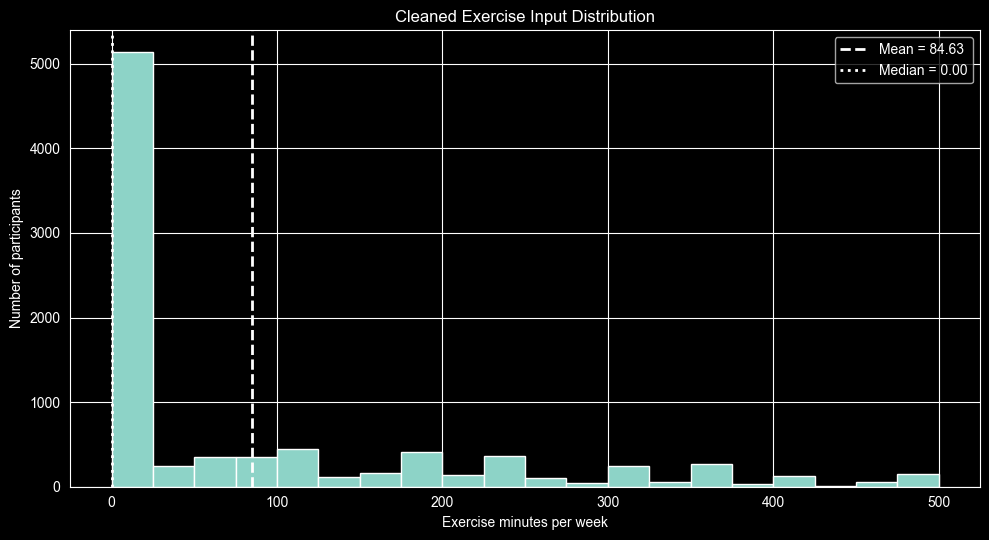

Graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\cleaned_exercise_distribution.png


In [8]:
import matplotlib.pyplot as plt

# Select cleaned exercise values
exercise_cleaned = exercise_analysis_clean["exercise_min_week"].dropna()

# Create the graph
plt.figure(figsize=(10, 5.5))

plt.hist(exercise_cleaned, bins=20)

plt.axvline(
    exercise_cleaned.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {exercise_cleaned.mean():.2f}"
)

plt.axvline(
    exercise_cleaned.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {exercise_cleaned.median():.2f}"
)

plt.title("Cleaned Exercise Input Distribution")
plt.xlabel("Exercise minutes per week")
plt.ylabel("Number of participants")
plt.legend()
plt.tight_layout()

# Save the graph
exercise_graph_path = GRAPH_DIR / "cleaned_exercise_distribution.png"
plt.savefig(exercise_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved to:")
print(exercise_graph_path)

---

# 9. ✧ Converting Weekly Exercise into Daily Exercise

The NHANES physical activity variables estimate exercise per week.

However, the installation represents one day.

To make the exercise input easier to use in the installation, we convert weekly exercise into an average daily value:

**exercise_min_day = exercise_min_week / 7**

This does not mean the participant exercised every day.

It means their total weekly recreational exercise is translated into an average number of exercise minutes per day.

We use the cleaned weekly exercise dataset, after statistical outliers were removed.


In [10]:
# Convert cleaned weekly exercise into average daily exercise
# ------------------------------------------------------------

exercise_daily_clean = exercise_analysis_clean.copy()

exercise_daily_clean["exercise_min_day"] = (
    exercise_daily_clean["exercise_min_week"] / 7
)

daily_exercise = exercise_daily_clean["exercise_min_day"].dropna()

print("Daily exercise input descriptive statistics")
print("-------------------------------------------")
print("Valid participants:", len(exercise_daily_clean))
print("Minimum:", round(daily_exercise.min(), 2), "minutes/day")
print("Maximum:", round(daily_exercise.max(), 2), "minutes/day")
print("Mean:", round(daily_exercise.mean(), 2), "minutes/day")
print("Median:", round(daily_exercise.median(), 2), "minutes/day")
print("Standard deviation:", round(daily_exercise.std(), 2), "minutes/day")

print("\nFull daily descriptive statistics:")
print(daily_exercise.describe().to_string())

# Create a clean table for display
daily_exercise_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(daily_exercise.count())} participants",
        f"{daily_exercise.min():.2f} minutes/day",
        f"{daily_exercise.quantile(0.25):.2f} minutes/day",
        f"{daily_exercise.median():.2f} minutes/day",
        f"{daily_exercise.mean():.2f} minutes/day",
        f"{daily_exercise.quantile(0.75):.2f} minutes/day",
        f"{daily_exercise.max():.2f} minutes/day",
        f"{daily_exercise.std():.2f} minutes/day"
    ],
    "Simple meaning": [
        "Number of valid participants after outlier cleaning",
        "Lowest average daily exercise estimate",
        "25% of participants were at or below this value",
        "Middle average daily exercise estimate",
        "Average daily exercise estimate",
        "75% of participants were at or below this value",
        "Highest average daily exercise estimate after cleaning",
        "How spread out the daily exercise values are"
    ]
})

display(daily_exercise_stats_table)

Daily exercise input descriptive statistics
-------------------------------------------
Valid participants: 8850
Minimum: 0.0 minutes/day
Maximum: 71.43 minutes/day
Mean: 12.09 minutes/day
Median: 0.0 minutes/day
Standard deviation: 18.27 minutes/day

Full daily descriptive statistics:
count    8850.000000
mean       12.090331
std        18.273824
min         0.000000
25%         0.000000
50%         0.000000
75%        20.000000
max        71.428571


,Statistic,Value,Simple meaning
0,Count,8850 participants,Number of valid participants after outlier cle...
1,Minimum,0.00 minutes/day,Lowest average daily exercise estimate
2,25th percentile,0.00 minutes/day,25% of participants were at or below this value
3,Median,0.00 minutes/day,Middle average daily exercise estimate
4,Mean,12.09 minutes/day,Average daily exercise estimate
5,75th percentile,20.00 minutes/day,75% of participants were at or below this value
6,Maximum,71.43 minutes/day,Highest average daily exercise estimate after ...
7,Standard deviation,18.27 minutes/day,How spread out the daily exercise values are


---

# 10. ✧ Graphing the Daily Exercise Distribution

Now we create a distribution graph for the daily exercise input variable.

This graph shows the spread of:

**exercise_min_day**

after outlier cleaning.

The daily value was calculated from the cleaned weekly value:

**exercise_min_day = exercise_min_week / 7**

This graph is useful for the installation because the installation represents one day, not a full week.


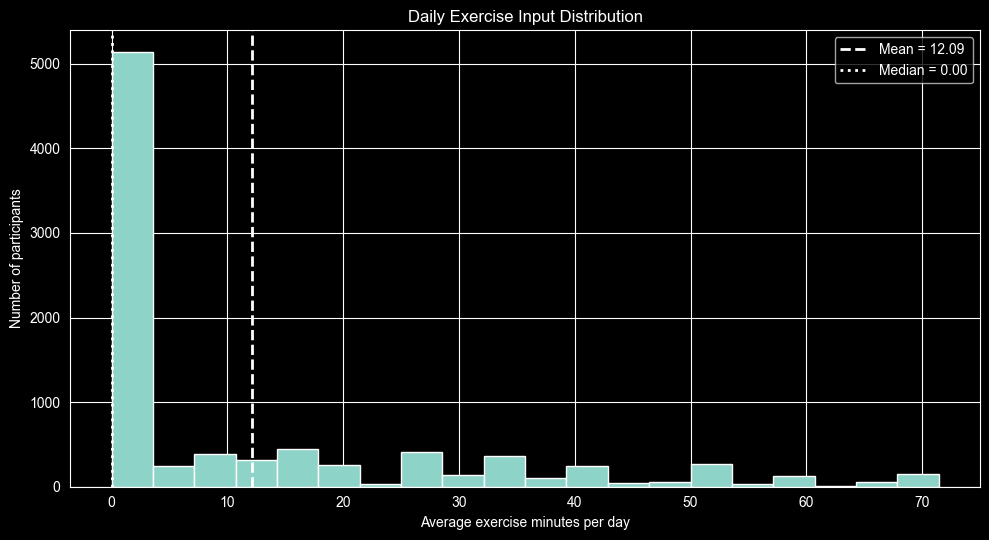

Graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\daily_exercise_distribution.png


In [11]:
import matplotlib.pyplot as plt

# Select daily exercise values
daily_exercise = exercise_daily_clean["exercise_min_day"].dropna()

# Create the graph
plt.figure(figsize=(10, 5.5))

plt.hist(daily_exercise, bins=20)

plt.axvline(
    daily_exercise.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {daily_exercise.mean():.2f}"
)

plt.axvline(
    daily_exercise.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {daily_exercise.median():.2f}"
)

plt.title("Daily Exercise Input Distribution")
plt.xlabel("Average exercise minutes per day")
plt.ylabel("Number of participants")
plt.legend()
plt.tight_layout()

# Save the graph
daily_exercise_graph_path = GRAPH_DIR / "daily_exercise_distribution.png"
plt.savefig(daily_exercise_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved to:")
print(daily_exercise_graph_path)